In [1]:
import os
import numpy as np
import pandas as pd
import sys
import tqdm

from scipy import optimize
from scipy import linalg
from scipy import interpolate
from scipy import signal
sys.path.append('..')
from anomalies.increasing import *
from anomalies.invariant import *
from anomalies.decreasing import *

import matplotlib.pyplot as plt
%matplotlib widget


In [2]:
# class Dataset():
    
#     def __init__(self, Xok=None, SNRdB=None):
        
#         self.values = Xok
#         # shape of the dataset
#         self.N, self.n = Xok.shape[0], Xok.shape[1]
        
#         # signal to noise ration fo the dataset
#         self.SNRdB = SNRdB
        
#         # statistics of the dataset
#         self.std, self.mean = Xok.std(), Xok.mean()
#         self.Sok = 1/(self.N-1) * Xok.T @ Xok
#         eigvals, eigvecs = np.linalg.eigh(self.Sok)
#         self.lok = eigvals[::-1]
#         self.Uok = eigvecs[:, ::-1]
#         self.energy_per_component = np.sum(self.lok) / self.n
        
#         # infer the dimension of the principal subspace (PS) k
#         singvalues = np.sqrt(self.lok)
#         if self.SNRdB is None:
#             threshold = 2.858 * np.median(singvalues)
#         else:
#             sigma = 10**(-self.SNRdB/20)
#             threshold = 4/np.sqrt(3) * sigma * np.sqrt(self.n)
        
#         dim_princ_sub = np.sum(singvalues > threshold)
#         if dim_princ_sub%2:
#             dim_princ_sub = dim_princ_sub+1
#         self.dim_princ_sub = dim_princ_sub
        
#         # principal subspace (PS) components
#         self.Uoks = self.Uok[:self.dim_princ_sub]
#         self.loks = self.lok[:self.dim_princ_sub]
#         # noise subspace (NS) components
#         self.Uokn = self.Uok[self.dim_princ_sub:]
#         self.lokn = self.lok[self.dim_princ_sub:]
#         # fraction of the signal energy contained in the PS
#         self.gamma = np.sum(self.loks) / self.n
        
# class Anomaly():
#     '''
#     parent class defining a template for 
#     the single anomalie class 
#     '''
#     def __init__(self, delta):
#         self.delta = delta
        
#     def __invert_deviation(self, delta):
#         self.param
        
    
#     def fit(self, dataset):
#         self.n = dataset.n
        
#     def distort(self):
        
#         return np.array()
    
# class TimeWarping(Anomaly):
    
#     def __init__(self, delta, fs=1):
#         super().__init__(delta)
#         self.alpha = None
#         self.fs = 1
    
#     def __bspline3(self, x):
#         return 1/6 * (np.max([0, 2-np.abs(x)])**3) \
#     - (2/3)*np.max([0, 1-np.abs(x)])**3

#     def __filt_bspline3(self, k):
#         a = -2 + np.sqrt(3)
#         return (-6*a)*(a**np.abs(k))/(1-a**2)
                                      
#     def __card_spline3(self, x, m=10):
#         return np.sum([
#             self.__filt_bspline3(k) * self.__bspline3(x-k)
#             for k in np.arange(-m, m)]
#         )
    
#     def __warpfun(self, tt, alpha):
#         return (1-alpha)*tt
    
#     def __deviation(self, alpha, dataset):
    
#         # deviation is computed through sinc interpolation
#         W_sinc = np.concatenate(
#             [
#                 np.sinc(self.__warpfun(i, alpha)-np.arange(self.n))
#                 for i in range(self.n)
#             ]
#         ).reshape(self.n, self.n)
        
        
#         # compute scaling parameters
#         Uok = dataset.Uok
#         lok = dataset.lok
#         Sok = dataset.Sok
        
#         scale1 = np.sqrt(np.trace(W_sinc.T @ W_sinc @ Sok) / self.n)
#         scale2 = np.sqrt(np.trace(Sok) / self.n)
#         V = Uok.T @ (W_sinc / scale1 * scale2).T @ Uok
#         return 2*scale2**2 - 2/n * np.sum(dataset.lok * np.diag(V))
    
#     def __invert_deviation(self, dataset):
#         # find and approximatin to alpha
#         alphas = np.linspace(0.5, 1, 100)
#         deviations = np.array(
#             [
#                 self.__deviation(alpha, dataset) for alpha in alphas],
#             dtype=np.float64
#         )
#         delta_alpha = lambda alpha : self.__deviation(alpha, dataset)\
#         - self.delta
#         alpha0 = alphas[np.argmin(np.abs(deviations - self.delta))]
        
#         # invert deviation starting from a good approximation
#         alpha = optimize.fsolve(delta_alpha, alpha0)[0]
#         return alpha
        
#     def fit(self, dataset):
#         super().fit(dataset)
    
#         # alpha corresponding to deviation level delta
#         self.alpha = self.__invert_deviation(dataset)
        
#         # warping matrix
#         W = np.zeros((self.n,self.n))
#         for j in range(self.n):
#             for i in range(self.n):
#                 W[j, i] = self.__card_spline3(
#                     self.fs*self.__warpfun(j/self.fs, self.alpha) - i
#                 )
#         self.scaling = np.sqrt(np.trace(dataset.Sok) \
#                                / np.trace(W.T @ W @ dataset.Sok))
        
#     def distort(self, Xok):
#         ndim = 2
#         if Xok.ndim == 1:
#             ndim = 1
#             Xok = Xok.reshape(1, self.n)
#         Xko = np.zeros(Xok.shape)
#         for i in range(len(Xok)):
#             # interpolate with spline
#             spline = interpolate.splrep(np.arange(self.n), Xok[i], s=0, k=3)
#             tt = self.__warpfun(np.arange(n)/self.fs, self.alpha)# warped time
#             Xko[i] = interpolate.splev(tt, spline, der=0)
#         # scale
#         Xko = self.scaling * Xko
#         if ndim==1:
#             Xko = Xko.reshape(self.n)
            
#         return Xko
    
    
# class SpectralAlteration(Anomaly):
#     def __init__(self, delta):
#         super().__init__(delta)
#         self.theta = None
        
#     def fit(self, dataset):
#         super().fit(dataset)
#         # theta corresponding to deviation delta
#         self.theta = self.__invert_deviation(dataset)
#         self.lok = dataset.lok
#         self.Uok = dataset.Uok

        
#         # rotation matrix of angle theta acting on the principal subspace
#         self.dim_princ_sub = dataset.dim_princ_sub
#         r_theta = lambda theta_: np.array([
#             [np.cos(theta_), -np.sin(theta_)],
#             [np.sin(theta_), np.cos(theta_)]
#         ])
#         thetas = self.theta * np.ones(self.dim_princ_sub//2)
#         self.Rb_theta = linalg.block_diag(
#             *[r_theta(thetas[i]) for i in range(self.dim_princ_sub//2)]
#         )
        
#     def __invert_deviation(self, dataset):
#         d_max = 2 * dataset.gamma
#         theta = np.arccos(1-self.delta/d_max)
#         return theta
        
#     def distort(self, Xok):
#         # genrate a random rotation matrix of angle theta acting 
#         # on the principal subspace
#         Q_ = np.random.normal(size=(self.dim_princ_sub, self.dim_princ_sub))    
#         Q = linalg.orth(Q_)
#         R_theta = Q @ self.Rb_theta @ Q.T
    
#         loks_sqrt = np.sqrt(self.lok[:self.dim_princ_sub])
#         lokn_sqrt = np.sqrt(self.lok[self.dim_princ_sub:])
#         # rotate sqrt of eighenvalues and build marix C
#         lkos_sqrt = R_theta @ loks_sqrt
#         lko_sqrt = np.concatenate([lkos_sqrt, lokn_sqrt])
#         C = self.Uok @ np.diag(lko_sqrt/np.sqrt(self.lok)) @ self.Uok.T
            
#         Xko = Xok @ C
        
#         return Xko
    
# class PrincipalSubspaceAlteration(Anomaly):
#     def __init__(self, delta):
#         super().__init__(delta)
#         self.theta = None
        
#     def fit(self, dataset):
#         super().fit(dataset)
#         # theta corresponding to deviation delta
#         self.theta = self.__invert_deviation(dataset)
#         # rotation matrix of angle theta rotating the principal subspace
#         self.dim_princ_sub = dataset.dim_princ_sub
#         r_theta = lambda theta_: np.array([
#             [np.cos(theta_), -np.sin(theta_)],
#             [np.sin(theta_), np.cos(theta_)]
#         ])
#         thetas = self.theta * np.ones(self.n//2)
#         self.Rb_theta = linalg.block_diag(
#             *[r_theta(thetas[i]) for i in range(self.n//2)]
#         )
        
#     def __invert_deviation(self, dataset):
#         d_max = 2 * dataset.energy_per_component
#         theta = np.arccos(1-self.delta/d_max)
#         return theta
        
#     def distort(self, Xok):
#         # genrate a random rotation matrix of angle theta 
#         # changing the principal subspace
#         Q_ = np.random.normal(size=(self.n, self.n))    
#         Q = linalg.orth(Q_)
#         R_theta = Q @ self.Rb_theta @ Q.T
#         C = R_theta.T
            
#         Xko = Xok @ C
        
#         return Xko
    

# class Clipping(Anomaly):
    
#     def __init__(self, delta, fs=1):
#         super().__init__(delta)
#         self.p = None
        
#     def __deviation(self, p, dataset):
#         # compute deviation through Monte Carlo
#         deviation = np.mean(
#             np.sum(
#                 (dataset.values - self.distort(dataset.values, p))**2, axis=1
#             )
#         )/dataset.n
#         return deviation
        
#     def __invert_deviation(self, dataset):
#         # limit cases
#         if self.delta == 1:
#             p = 1         
#         elif self.delta == 0:
#             p = 0
#          # invert deviation 
#         else: 
#             delta_p = lambda p : self.__deviation(p, dataset) - self.delta
#             p = optimize.brentq(delta_p, a=0.01, b=0.99)
#         return p
        
#     def fit(self, dataset):
#         super().fit(dataset)
#         # theta corresponding to deviation delta
#         self.p = self.__invert_deviation(dataset)
        
#     def distort(self, Xok, p=None):
#         if p is None:
#             p = self.p
#         # limit cases
#         if p == 1:
#             Xko = np.zeros(Xok.shape)      
#         elif p == 0:
#             Xko = Xok     
#         else:
#             N = Xok.shape[0]
#             Xko = np.nan * np.ones(Xok.shape)
#             i = int(p * n) + 1
#             # threshold for each instance
#             th = np.sort(np.abs(Xok), axis=-1)[..., i, None]
#             idx = np.abs(Xok) > th
#             Xko = np.sign(Xok) * idx * th
#             Xko[~idx] = Xok[~idx]
#         return Xko
    
    
# class DeadZone(Clipping):
#     def distort(self, Xok, p=None):
#         # limit cases
#         if p is None:
#             p = self.p
#         if p == 1:
#             Xko = np.zeros(Xok.shape)      
#         elif p == 0:
#             Xko = Xok     
#         else:
#             N = Xok.shape[0]
#             Xko = np.nan * np.ones(Xok.shape)
#             i = int(p * n) + 1
#         # threshold for each instance
#             th = np.sort(np.abs(Xok), axis=-1)[..., i, None]
#             idx = np.abs(Xok) > th
#             Xko = np.zeros(Xok.shape)
#             Xko[idx] = Xok[idx]
#         return Xko

# class Disturbace(Anomaly):
#     def __init__(self, delta, fs=1):
#         super().__init__(delta)
#         self.a = self.__invert_deviation()
    
#     def __invert_deviation(self):
#         return np.sqrt(self.delta)
    
#     def generate(self, N):
#         return disurbance
    
#     def distort(self, Xok):
#         if Xok.ndim == 1:
#             N = 1
#         else:
#             N = len(Xok)
#         disturbance = self.generate(N)
#         return disturbance + Xok 

# class Constant(Disturbace):
    
#     def generate(self, N):
#         # sing of the constant distrubance
#         sign_array = np.random.choice(np.arange(-1, 2, 2), size=N)[..., None]
#         disturbance = self.a * sign_array * np.ones(shape=(N, self.n))
#         if N == 1:
#             disturbance = disturbance[0]
#         return disturbance
    
# class Step(Disturbace):
    
#     def generate(self, N):
#         # randomly select rising or falling step
#         r_array = np.random.choice(np.arange(-1, 2, 2), size=N)[..., None]
#         # step position in the middle of the instance
#         j_array = (self.n//2) * np.ones(shape=N, dtype=int)
#         # sing of the constant distrubance
#         sign_array = np.random.choice(np.arange(-1, 2, 2), size=N)[..., None]
        
#         disturbance =  np.array(
#             [np.concatenate([
#                 np.sqrt(self.n/j) * 0.5*(1 + r) * np.ones(shape=j),
#                 np.sqrt(self.n/(self.n-j)) * 0.5*(1 - r) * np.ones(shape = self.n-j)
#         ])
#              for j, r in zip(j_array, r_array)])
#         disturbance = self.a * sign_array * disturbance
        
#         if N == 1:
#             disturbance = disturbance[0]
#         return disturbance
    
# class Impulse(Disturbace):

#     def generate(self, N):
#         # impulse position in the middle of the instance
#         j_array = (self.n//2) * np.ones(shape=N, dtype=int)
#         # sing of the constant distrubance
#         sign_array = np.random.choice(np.arange(-1, 2, 2), size=N)[..., None]
        
#         disturbance = np.zeros(shape=(N, self.n))
#         idx = np.arange(N)
#         disturbance[(idx, j_array[idx])] = np.sqrt(self.n)
#         disturbance = self.a * sign_array * disturbance
        
#         if N == 1:
#             disturbance = disturbance[0]
#         return disturbance

# class GWN(Disturbace):
        
#     def generate(self, N):
#         disturbance = self.a * np.random.normal(size=(N, self.n))
#         if N == 1:
#             disturbance = disturbance[0]      
#         return disturbance
    
# class GNN(Disturbace):
        
#     def generate(self, N):
                
#         window='boxcar'
#         pass_zero='bandpass'
#         num_taps=1001
#         length = self.n + num_taps
#         fs = 1
#         band = [0, fs/2]
        
#         i = 0
        
#         # generate bandwidths for each distrubance instance
#         fmins_array = np.random.uniform(band[0], band[1], N)
#         fmax_array = np.array(
#             [np.random.uniform(fmin, band[1]) for fmin in fmins_array]
#         )
#         band_array = fmax_array - fmins_array
#         f0_array = (fmins_array + fmins_array)/2
        
#         Cols = np.ones((self.n, self.n)) * np.arange(0, self.n)
#         Rows = Cols.T
#         Lags = Rows - Cols
            
#         disturbance = np.zeros((N, self.n))
#         for f0, band in zip(f0_array, band_array):
#             try:
#                 disturbance[i] = np.random.multivariate_normal(
#                     mean=np.zeros(self.n),
#                     cov=np.cos(2*np.pi*Lags*f0) * np.sinc(Lags*band),
#                     size=1)
#             except:
#                 awgn = np.random.normal(size=length)
#                 taps = signal.firwin(
#                     numtaps=num_taps,
#                     cutoff=[f0 - band/2, f0 + band/2],
#                     width=None,
#                     window=window,
#                     pass_zero=pass_zero,
#                     scale=True,
#                     fs=1
#                 )
#                 filtered = signal.lfilter(taps, 1.0, awgn)[num_taps : num_taps + self.n] 
#                 disturbance[i] = filtered/ np.sqrt(np.sum(taps**2))
                
#             i = i+1
            
#         disturbance = self.a * disturbance
        
#         if N == 1:
#             disturbance = disturbance[0]
                
#         return disturbance
    
# class MixingGWN(GWN):
#     def __invert_deviation(self):
#         return np.sqrt( 1 - (1 - self.delta / 2)**2)
#     def distort(self, Xok):
#         if Xok.ndim == 1:
#             N = 1
#         else:
#             N = len(Xok)
#         disturbance = self.generate(N)
#         return disturbance + np.sqrt(1-self.a**2) * Xok 
    
# class MixingConstant(Constant):
#     def __invert_deviation(self):
#         return np.sqrt( 1 - (1 - self.delta / 2)**2)
#     def distort(self, Xok):
#         if Xok.ndim == 1:
#             N = 1
#         else:
#             N = len(Xok)
#         disturbance = self.generate(N)
#         return disturbance + np.sqrt(1-self.a**2) * Xok 
    

           

## PREPARE DATASET

In [3]:
# load data
n = 256
SNRdB = 40
path_test = os.path.join('..', '..', '..', 'ecg-data', f'ecgSyn_n={n}_scaled_test_snr={SNRdB}dB.pkl')
# process data
Xok_test = pd.read_pickle(path_test).dropna(axis=0)
nch = 1
ninst = 10_000
Xok_test = Xok_test.values[:ninst, 0:n].reshape((ninst, -1))
xok_test = Xok_test[0]
# build a dataset

## Generate Anomalies with a given deviation

In [4]:
delta = 1.8

In [16]:
anomalies_labels = [
    'GWN', 'Constant', 'Step', 'Impulse', 'GNN',
    'TimeWarping', 'SpectralAlteration', 'PrincipalSubspaceAlteration',
    'MixingGWN', 'MixingConstant',
    'Clipping', 'Dead-Zone'
]

# create anomalies class instance
anomalies = [
    GWN(delta), Constant(delta), Step(delta), Impulse(delta), GNN(delta),
    TimeWarping(delta), SpectralAlteration(delta), PrincipalSubspaceAlteration(delta),
    MixingGWN(delta), MixingConstant(delta),
    Clipping(delta), DeadZone(delta)
]

anomalies_dict = dict(zip(anomalies_labels, anomalies))

In [17]:
# initialize the dataframe for anomalous data
Xko_df = pd.DataFrame(
    index=np.arange(Xok_test.shape[0]),
    columns=pd.MultiIndex.from_product([anomalies_labels, np.arange(Xok_test.shape[1])])
)

In [18]:
# generate anomalous data for each anomaly
for name, anomaly in tqdm.tqdm(anomalies_dict.items()):
    anomaly.fit(Xok_test)
    if name in ['SpectralAlteration', 'PrincipalSubspaceAlteration']:
        anomaly.fit(Xok_test, SNRdB)
    # Xko_df.loc[0, name] = anomaly.distort(ECG_test.values[0])
    Xko_df[name] = anomaly.distort(Xok_test)

100%|███████████████████████████████████████████| 12/12 [04:25<00:00, 22.13s/it]


In [19]:
# check deviation levels through Monte Carlo
print('deviation for :\n')
for name in anomalies_dict.keys():
    print(f'{name}: {np.round(np.mean(np.sum((Xok_test - Xko_df[name].values)**2, axis=1))/Xok_test.shape[-1], 3)}')

deviation for :

GWN: 1.801
Constant: 1.8
Step: 1.8
Impulse: 1.8
GNN: 1.809
TimeWarping: 1.8
SpectralAlteration: 1.8
PrincipalSubspaceAlteration: 1.8
MixingGWN: 1.799
MixingConstant: 1.8
Clipping: 0.999
Dead-Zone: 0.999


## Plot an example for each anomaly

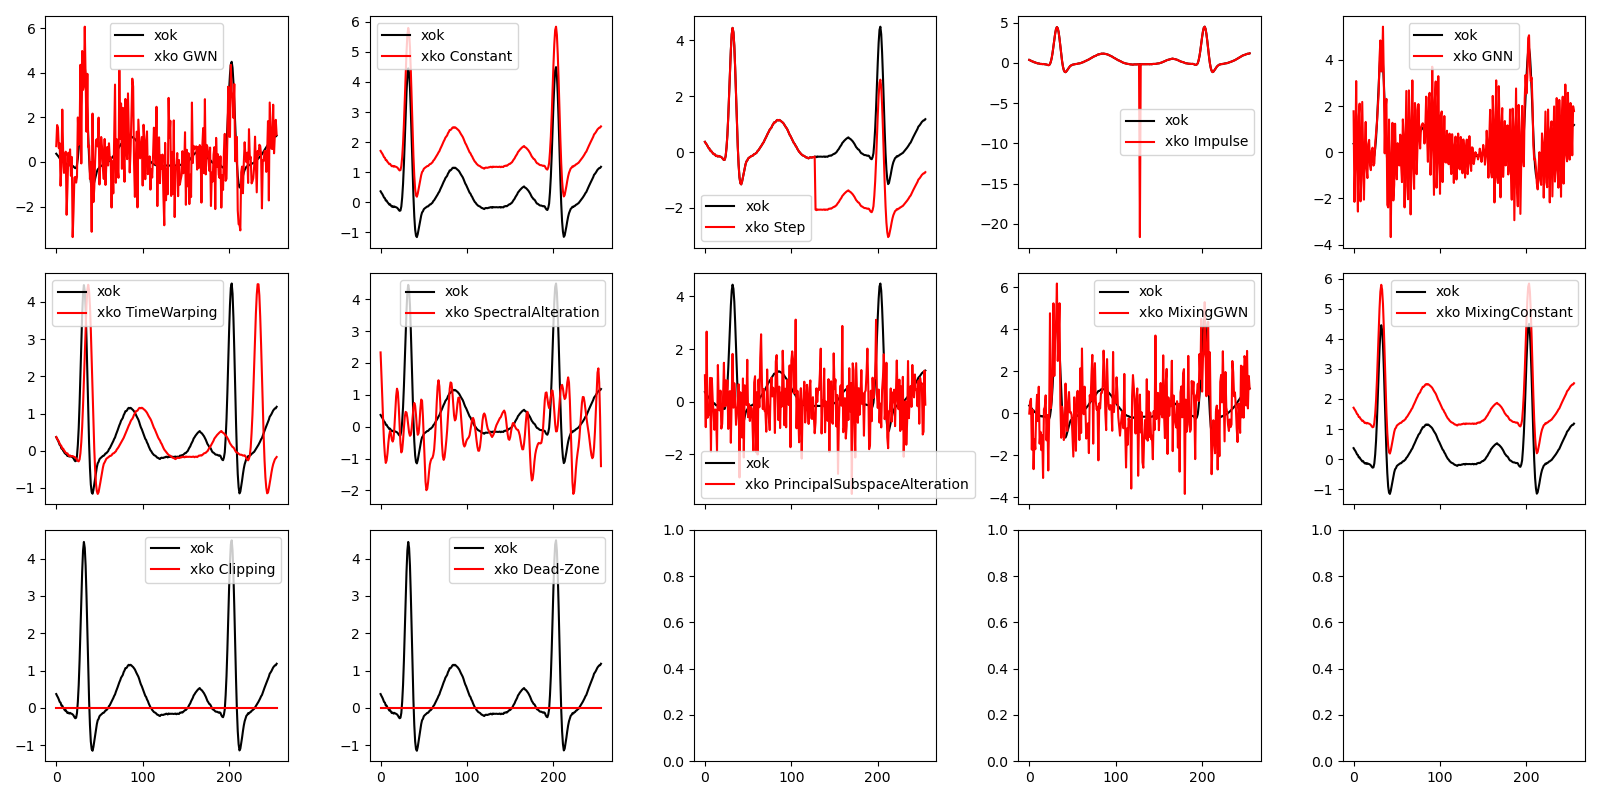

In [20]:
fig, ax = plt.subplots(3, 5, figsize=(16, 8), sharex=True, sharey=False)
ax = ax.flatten()
for name, ax_ in zip(anomalies_dict.keys(), ax):
    ax_.plot(Xok_test[0], label='xok', c='k')
    ax_.plot(Xko_df.loc[0, name], label=f'xko {name}', c='r')
    ax_.legend()
fig.tight_layout()

In [21]:
class Disturbance(Anomaly):
    def __init__(self, delta):
        super().__init__(delta)
        self.a = self._invert_deviation()
    
    def _invert_deviation(self):
        return np.sqrt(self.delta)
    
    def generate(self, N):
        return disurbance
    
    def distort(self, Xok):
        if Xok.ndim == 1:
            N = 1
        else:
            N = Xok.shape[-2]
        disturbance = self.generate(N)
        return disturbance + Xok 

class GNN2(Disturbance):
        
    def generate(self, N):
                
        window='boxcar'
        pass_zero='bandpass'
        num_taps=1001
        length = self.n + num_taps
        fs = 1
        band = [0, fs/2]
        
        # generate bandwidths for each distrubance instance
        fmins_array = np.random.uniform(band[0], band[1], N)
        fmax_array = np.array(
            [np.random.uniform(fmin, band[1]) for fmin in fmins_array]
        )
        band_array = fmax_array - fmins_array
        f0_array = (fmins_array + fmins_array)/2
        
        # define the lags        
        Cols = np.ones((self.n, self.n)) * np.arange(0, self.n)
        Rows = Cols.T
        Lags = Rows - Cols
            
        disturbance = np.zeros((N, self.n))
        
        i = 0
        
        for f0, band in zip(f0_array, band_array):
            try:
                disturbance[i] = np.random.multivariate_normal(
                    mean=np.zeros(self.n),
                    cov=np.cos(2*np.pi*Lags*f0) * np.sinc(Lags*band),
                    size=1)
            except:
                awgn = np.random.normal(size=length)
                taps = signal.firwin(
                    numtaps=num_taps,
                    cutoff=[f0 - band/2, f0 + band/2],
                    width=None,
                    window=window,
                    pass_zero=pass_zero,
                    scale=True,
                    fs=1
                )
                filtered = signal.lfilter(taps, 1.0, awgn)[num_taps : num_taps + self.n] 
                disturbance[i] = filtered/ np.sqrt(np.sum(taps**2))
                
            i = i+1
            
        disturbance = self.a * disturbance
        
        if N == 1:
            disturbance = disturbance[0]
                
        return disturbance